# 01 — Data Exploration

> **Goal:** descriptive statistics and sanity checks on the Phase 0 dataset
> before any hypothesis testing.
>
> **Author:** Lucas Marque  
> **Date:** April 18, 2026  
> **Project:** [polymarket-calibration-study](https://github.com/l-marque/polymarket-calibration-study)

This notebook produces the descriptive baseline that informs all subsequent
analyses. No hypothesis testing is performed here. Holdout markets (resolved
within the last 30 days) are excluded from all queries.

In [67]:
# Standard scientific stack
import sys
import sqlite3
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Project root: allow importing our own modules from the notebook
PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

# Database path — explicitly anchored to project root, not to cwd.
# This is more robust than the default DB_PATH which resolves relative to cwd.
DB_PATH = PROJECT_ROOT / "polymarket.db"

# Display settings
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 180)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"] = 100

print(f"Python       : {sys.version.split()[0]}")
print(f"Pandas       : {pd.__version__}")
print(f"NumPy        : {np.__version__}")
print(f"Project root : {PROJECT_ROOT}")
print(f"Database     : {DB_PATH}")
print(f"Exists       : {DB_PATH.exists()}")

Python       : 3.12.10
Pandas       : 2.3.3
NumPy        : 2.4.4
Project root : c:\Users\lucas\polymarket-calibration-study
Database     : c:\Users\lucas\polymarket-calibration-study\polymarket.db
Exists       : True


## 1. Database Schema and Coverage

We start by inspecting the structure of the SQLite database produced by Phase 0:
which tables exist, what columns they hold, and how many rows are in each.
This is a sanity check before any analysis: if `markets` is empty or
`price_history` is missing, no downstream analysis will work.

In [68]:
def inspect_db(db_path: Path) -> None:
    """List all tables in the database with their column schema and row count."""
    conn = sqlite3.connect(db_path)
    try:
        tables = pd.read_sql_query(
            "SELECT name FROM sqlite_master WHERE type='table' ORDER BY name",
            conn,
        )["name"].tolist()

        print(f"Tables found: {len(tables)}\n")

        for t in tables:
            n_rows = conn.execute(f"SELECT COUNT(*) FROM {t}").fetchone()[0]
            cols = pd.read_sql_query(f"PRAGMA table_info({t})", conn)
            print(f"  {t:20s} {n_rows:>10,} rows | {len(cols)} columns")
            for _, row in cols.iterrows():
                pk = " (PK)" if row["pk"] else ""
                nn = " NOT NULL" if row["notnull"] else ""
                print(f"      {row['name']:25s} {row['type']:10s}{nn}{pk}")
            print()
    finally:
        conn.close()


inspect_db(DB_PATH)

Tables found: 5

  collection_runs               5 rows | 8 columns
      id                        INTEGER    (PK)
      started_ts                INTEGER    NOT NULL
      finished_ts               INTEGER   
      kind                      TEXT       NOT NULL
      params_json               TEXT      
      rows_written              INTEGER   
      status                    TEXT      
      error                     TEXT      

  macro_series             10,830 rows | 4 columns
      series_id                 TEXT       NOT NULL (PK)
      ts                        INTEGER    NOT NULL (PK)
      value                     REAL      
      fetched_ts                INTEGER    NOT NULL

  markets                  99,999 rows | 21 columns
      market_id                 TEXT       (PK)
      question                  TEXT       NOT NULL
      slug                      TEXT      
      category                  TEXT      
      tags_json                 TEXT      
      yes_token_id    

## 2. Temporal Coverage

When were these markets active? When did they resolve? Understanding the
temporal distribution is critical: if 90% of our markets resolved during a
single political event (e.g. US 2024 election), our results may not generalize.
We also want to verify that the holdout flag is correctly set.

In [69]:
conn = sqlite3.connect(DB_PATH)

markets = pd.read_sql_query(
    """
    SELECT
        market_id,
        question,
        slug,
        category,
        yes_token_id,
        no_token_id,
        start_ts,
        end_ts,
        resolved_ts,
        resolved_outcome,
        volume_total_usd,
        liquidity_usd,
        closed,
        holdout
    FROM markets
    """,
    conn,
    parse_dates=False,
)
conn.close()

# Convert Unix timestamps to datetime for human-readable analysis
for col in ["start_ts", "end_ts", "resolved_ts"]:
    markets[col + "_dt"] = pd.to_datetime(markets[col], unit="s", errors="coerce")

print(f"Total markets : {len(markets):,}")
print(f"Closed        : {markets['closed'].sum():,}")
print(f"Holdout       : {markets['holdout'].sum():,}")
print(f"Eligible      : {((markets['closed']==1) & (markets['holdout']==0)).sum():,}")
print()
print("End date range (closed markets):")
closed = markets[markets["closed"] == 1]
print(f"  Earliest : {closed['end_ts_dt'].min()}")
print(f"  Latest   : {closed['end_ts_dt'].max()}")
print(f"  Span     : {(closed['end_ts_dt'].max() - closed['end_ts_dt'].min()).days} days")

Total markets : 99,999
Closed        : 99,999
Holdout       : 75,932
Eligible      : 24,067

End date range (closed markets):
  Earliest : 2025-04-26 12:00:00
  Latest   : 2028-01-01 05:00:00
  Span     : 979 days


In [70]:
# Diagnostic 1: distribution of end_ts across years
print("=== Distribution of end_ts by year (closed markets) ===")
year_counts = closed["end_ts_dt"].dt.year.value_counts().sort_index()
print(year_counts)
print()

# Diagnostic 2: future-dated "closed" markets
now = pd.Timestamp.utcnow().tz_localize(None)
future = closed[closed["end_ts_dt"] > now]
print(f"Closed markets with end_ts in the future: {len(future):,}")
print(f"  As fraction of all closed: {len(future)/len(closed):.1%}")
print()

# Diagnostic 3: cross-tab of holdout flag vs end_ts age
closed_eligible = closed[closed["end_ts_dt"] <= now].copy()
closed_eligible["age_days"] = (now - closed_eligible["end_ts_dt"]).dt.days
closed_eligible["age_bucket"] = pd.cut(
    closed_eligible["age_days"],
    bins=[-1, 30, 90, 365, 99999],
    labels=["<30d", "30-90d", "90-365d", ">365d"]
)
print("=== Holdout flag vs market age (past markets only) ===")
print(pd.crosstab(closed_eligible["age_bucket"], closed_eligible["holdout"], margins=True))

=== Distribution of end_ts by year (closed markets) ===
end_ts_dt
2,025.0000    29670
2,026.0000    70024
2,027.0000       91
2,028.0000       10
Name: count, dtype: int64

Closed markets with end_ts in the future: 1,172
  As fraction of all closed: 1.2%

=== Holdout flag vs market age (past markets only) ===
holdout         0      1    All
age_bucket                     
<30d         5180  26065  31245
30-90d       6922  23458  30380
90-365d     11513  25485  36998
All         23615  75008  98623


In [71]:
# === Recompute clean flags from raw data ===
# We do NOT modify the database. We add computed columns to the in-memory
# DataFrame. The original `closed` and `holdout` columns are preserved for
# transparency, but downstream analysis uses our cleaned flags.

now = pd.Timestamp.utcnow().tz_localize(None)
HOLDOUT_DAYS = 30

# truly_resolved: market is genuinely past, with a real binary outcome
markets["truly_resolved"] = (
    (markets["closed"] == 1)
    & (markets["end_ts_dt"] <= now)
    & (markets["resolved_outcome"].isin(["YES", "NO"]))
)

# resolution_age_days: how long ago the market resolved (NaN if not resolved)
markets["resolution_age_days"] = (now - markets["end_ts_dt"]).dt.days

# truly_holdout: resolved within last 30 days, reserved for final validation
markets["truly_holdout"] = (
    markets["truly_resolved"]
    & (markets["resolution_age_days"] < HOLDOUT_DAYS)
)

# analysis_set: what we work with for exploration & hypothesis testing
markets["analysis_set"] = markets["truly_resolved"] & ~markets["truly_holdout"]

# Sanity check: comparison
print("=== Comparison: original vs cleaned flags ===\n")
print(f"Total markets                : {len(markets):,}")
print(f"Originally `closed=1`        : {(markets['closed']==1).sum():,}")
print(f"truly_resolved (cleaned)     : {markets['truly_resolved'].sum():,}")
print()
print(f"Originally `holdout=1`       : {(markets['holdout']==1).sum():,}")
print(f"truly_holdout (cleaned)      : {markets['truly_holdout'].sum():,}")
print()
print(f"Original 'eligible' set      : {((markets['closed']==1) & (markets['holdout']==0)).sum():,}")
print(f"NEW analysis_set             : {markets['analysis_set'].sum():,}")
print()
print("=== Quality breakdown of analysis_set ===")
analysis = markets[markets["analysis_set"]]
print(f"  YES outcomes               : {(analysis['resolved_outcome']=='YES').sum():,}")
print(f"  NO outcomes                : {(analysis['resolved_outcome']=='NO').sum():,}")
print(f"  YES rate                   : {(analysis['resolved_outcome']=='YES').mean():.1%}")
print(f"  Median age (days)          : {analysis['resolution_age_days'].median():.0f}")
print(f"  Min age (days)             : {analysis['resolution_age_days'].min():.0f}")
print(f"  Max age (days)             : {analysis['resolution_age_days'].max():.0f}")

=== Comparison: original vs cleaned flags ===

Total markets                : 99,999
Originally `closed=1`        : 99,999
truly_resolved (cleaned)     : 98,079

Originally `holdout=1`       : 75,932
truly_holdout (cleaned)      : 30,945

Original 'eligible' set      : 24,067
NEW analysis_set             : 67,134

=== Quality breakdown of analysis_set ===
  YES outcomes               : 27,756
  NO outcomes                : 39,378
  YES rate                   : 41.3%
  Median age (days)          : 97
  Min age (days)             : 30
  Max age (days)             : 357


## 3. Resolution Outcome Distribution

What fraction of markets resolve YES vs NO? A naive expectation would be ~50/50,
but several mechanisms could bias this:
- **Question framing bias**: market creators might phrase questions in a way
  that the "default" answer is more often NO (e.g. "Will X happen by date Y?").
- **Category mix**: sports markets are typically near 50/50, while political
  surprise markets (e.g. "Will candidate Z drop out?") skew NO.

A baseline rate far from 50% will affect any naive trading strategy.

In [72]:
import json

# Look at one raw market payload to understand what fields are actually present
conn = sqlite3.connect(DB_PATH)
sample = pd.read_sql_query(
    "SELECT market_id, question, category, tags_json, raw_json FROM markets LIMIT 3",
    conn,
)
conn.close()

for i, row in sample.iterrows():
    print(f"--- Market {i+1}: {row['question'][:80]}...")
    print(f"  category column     : {row['category']!r}")
    print(f"  tags_json column    : {row['tags_json'][:200] if row['tags_json'] else 'NULL'}")
    print()
    raw = json.loads(row["raw_json"])
    # Show fields that might contain category info
    keys_of_interest = ["category", "eventCategory", "tags", "events", "groupItemTitle",
                        "categorySlug", "slug", "subType"]
    for k in keys_of_interest:
        if k in raw:
            v = raw[k]
            v_str = str(v)[:200] if v else "(empty)"
            print(f"  raw.{k}: {v_str}")
    print()

--- Market 1: Counter-Strike: Acend vs Bebop (BO3) - CCT Europe Series #14 Play-In Group B...
  category column     : None
  tags_json column    : []

  raw.events: [{'id': '179909', 'ticker': 'cs2-ace1-bbp-2026-01-23', 'slug': 'cs2-ace1-bbp-2026-01-23', 'title': 'Counter-Strike: Acend vs Bebop (BO3) - CCT Europe Series #14 Play-In Group B', 'description': 'This 
  raw.groupItemTitle: Match Winner
  raw.slug: cs2-ace1-bbp-2026-01-23

--- Market 2: Will the price of Bitcoin be above $110,000 on September 26 at 4AM ET?...
  category column     : None
  tags_json column    : []

  raw.events: [{'id': '49983', 'ticker': 'btc-multistrike-4h-1758873600', 'slug': 'btc-multistrike-4h-1758873600', 'title': 'Bitcoin above ___ on September 26, 4AM ET?', 'description': 'This market will resolve to 
  raw.groupItemTitle: 110,000
  raw.slug: btc-multistrike-4h-1758873600-110k

--- Market 3: Martin vs. Jianu: Match O/U 21.5...
  category column     : None
  tags_json column    : []

  raw.events: [{'

In [73]:
# Re-derive category from slug patterns since tags_json is empty in the API responses.
# This is a rule-based classifier; not perfect, but sufficient for stratification.

def categorize_from_slug(slug: str | None) -> str:
    """Map a market slug to a coarse category based on prefix patterns."""
    if not slug or not isinstance(slug, str):
        return "unknown"
    s = slug.lower()

    # Crypto
    if any(s.startswith(p) for p in ["btc-", "eth-", "sol-", "xrp-", "doge-", "bitcoin-", "crypto-"]):
        return "crypto"

    # Sports — esports
    if any(s.startswith(p) for p in ["cs2-", "csgo-", "lol-", "dota-", "valorant-"]):
        return "esports"

    # Sports — traditional (tennis ATP/WTA, NFL, NBA, MLB, NHL, soccer, F1, golf, UFC, NCAA)
    if any(s.startswith(p) for p in ["atp-", "wta-", "nfl-", "nba-", "mlb-", "nhl-",
                                       "ncaaf-", "ncaab-", "ufc-", "f1-", "pga-", "epl-",
                                       "laliga-", "bundesliga-", "seriea-", "ligue1-",
                                       "ucl-", "uel-", "soccer-", "tennis-", "boxing-"]):
        return "sports"

    # Politics
    if any(k in s for k in ["election", "trump", "biden", "harris", "vance", "vote", 
                              "president", "congress", "senate", "primary", "potus",
                              "putin", "zelensky", "macron", "starmer", "merkel",
                              "republican", "democrat", "gop"]):
        return "politics"

    # Geopolitics / world events
    if any(k in s for k in ["ukraine", "russia", "china", "iran", "israel", "gaza",
                              "nato", "war", "ceasefire", "treaty", "summit"]):
        return "geopolitics"

    # Macro / finance
    if any(k in s for k in ["fed-", "fomc-", "rate-cut", "rate-hike", "inflation",
                              "cpi-", "gdp-", "recession", "spx-", "stock-"]):
        return "macro"

    # Entertainment
    if any(k in s for k in ["oscar", "grammy", "emmy", "movie", "boxoffice", "netflix"]):
        return "entertainment"

    return "other"


# Apply to the analysis set
markets["category_derived"] = markets["slug"].apply(categorize_from_slug)

# Show the new distribution
print("=== Derived category distribution (analysis_set) ===")
analysis = markets[markets["analysis_set"]].copy()
cat_counts = analysis["category_derived"].value_counts()
print(cat_counts)
print()
print(f"Coverage: {(analysis['category_derived'] != 'unknown').sum() / len(analysis):.1%} of markets categorized")
print(f"In 'other': {(analysis['category_derived'] == 'other').sum():,} markets — examine these to refine rules")

# Show a sample of "other" to see what we're missing
print("\n=== Sample of 10 'other' markets (to refine rules) ===")
others = analysis[analysis["category_derived"] == "other"]["slug"].dropna().sample(min(10, len(analysis[analysis["category_derived"] == "other"])), random_state=42)
for s in others:
    print(f"  {s}")

=== Derived category distribution (analysis_set) ===
category_derived
other            29569
crypto           19994
sports           11895
esports           3311
politics          1333
geopolitics        764
entertainment      159
macro              109
Name: count, dtype: int64

Coverage: 100.0% of markets categorized
In 'other': 29,569 markets — examine these to refine rules

=== Sample of 10 'other' markets (to refine rules) ===
  will-simone-bolelli-and-andrea-vavassori-win-the-2025-rolex-paris-masters-mens-doubles-tournament
  sea-mil-lec-2026-01-18-total-4pt5
  fl1-lil-tou-2025-09-14-tou
  scop-dfc-hib-2026-02-28-total-4pt5
  will-denis-shapovalov-win-the-2025-french-open
  dota2-wb-strong-2026-02-04-game2
  will-the-price-of-ethereum-be-between-2700-2800-on-january-31
  andrew-tate-of-tweets-february-24-march-3-2026-0-99
  por-rio-mor-2026-02-16-total-3pt5
  will-the-official-usd-to-ars-exchange-rate-be-between-1325pt00-and-1349pt99-on-december-31-2025


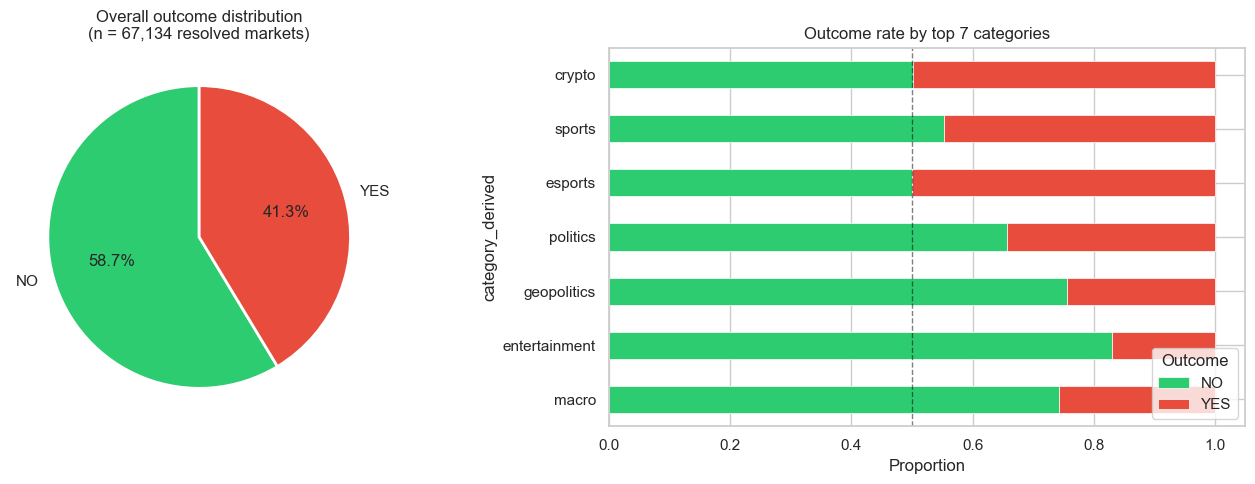


Overall YES rate: 41.3%
Overall NO rate : 58.7%
Markets with category info: 37,565 / 67,134 (56.0%)

No categories with >= 100 markets.


In [74]:
analysis = markets[markets["analysis_set"]].copy()

# Filter out NULL categories for the per-category plot
analysis_with_cat = analysis[analysis["category_derived"] != "other"].copy()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: pie chart of overall YES vs NO
outcome_counts = analysis["resolved_outcome"].value_counts()
colors = ["#2ecc71", "#e74c3c"]
axes[0].pie(
    outcome_counts.values,
    labels=outcome_counts.index,
    autopct="%1.1f%%",
    colors=colors,
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 2},
)
axes[0].set_title(f"Overall outcome distribution\n(n = {len(analysis):,} resolved markets)")

# Right: outcome rate by top categories (excluding NULL)
top_cats = analysis_with_cat["category_derived"].value_counts().head(10).index.tolist()
cat_outcomes = (
    analysis_with_cat[analysis_with_cat["category_derived"].isin(top_cats)]
    .groupby("category_derived")["resolved_outcome"]
    .value_counts(normalize=True)
    .unstack(fill_value=0)
    .reindex(top_cats)
    .astype(float)  # force numeric
)

if not cat_outcomes.empty and cat_outcomes.sum().sum() > 0:
    cat_outcomes.plot(
        kind="barh", stacked=True, ax=axes[1],
        color=colors, edgecolor="white", linewidth=0.5,
    )
    axes[1].axvline(0.5, color="black", linestyle="--", linewidth=1, alpha=0.5)
    axes[1].set_xlabel("Proportion")
    axes[1].set_title(f"Outcome rate by top {len(top_cats)} categories")
    axes[1].legend(title="Outcome", loc="lower right")
    axes[1].invert_yaxis()
else:
    axes[1].text(0.5, 0.5, "No category data available",
                 ha="center", va="center", transform=axes[1].transAxes)
    axes[1].set_title("Categories (no data)")

plt.tight_layout()
plt.show()

print(f"\nOverall YES rate: {(analysis['resolved_outcome']=='YES').mean():.1%}")
print(f"Overall NO rate : {(analysis['resolved_outcome']=='NO').mean():.1%}")
print(f"Markets with category info: {len(analysis_with_cat):,} / {len(analysis):,} ({len(analysis_with_cat)/len(analysis):.1%})")

# Per-category YES rates with sample size threshold
cat_yes = (
    analysis_with_cat.groupby("category")["resolved_outcome"]
    .apply(lambda x: (x == "YES").mean())
)
n_cat = analysis_with_cat["category"].value_counts()
cat_summary = pd.DataFrame({"yes_rate": cat_yes, "n_markets": n_cat}).dropna()
cat_summary = cat_summary[cat_summary["n_markets"] >= 100].sort_values("yes_rate")

if len(cat_summary) > 0:
    print(f"\nLowest YES rates (n >= 100):")
    print(cat_summary.head(5).to_string())
    print(f"\nHighest YES rates (n >= 100):")
    print(cat_summary.tail(5).to_string())
else:
    print("\nNo categories with >= 100 markets.")

In [75]:
def categorize_from_slug_v2(slug: str | None) -> str:
    """Improved rule-based classifier from slug patterns."""
    if not slug or not isinstance(slug, str):
        return "unknown"
    s = slug.lower()

    # CRYPTO — added solana, ethereum, ripple, dogecoin, ada, bnb, polygon variations
    crypto_prefixes = ["btc-", "eth-", "sol-", "xrp-", "doge-", "ada-", "bnb-",
                        "matic-", "avax-", "link-", "ltc-", "bitcoin-", "ethereum-",
                        "solana-", "ripple-", "crypto-"]
    crypto_keywords = ["bitcoin", "ethereum", "solana", "btc-above", "eth-above",
                        "sol-above", "btc-below", "eth-below"]
    if any(s.startswith(p) for p in crypto_prefixes) or any(k in s for k in crypto_keywords):
        return "crypto"

    # ESPORTS — added val (Valorant), r6 (Rainbow Six), apex
    esports_prefixes = ["cs2-", "csgo-", "lol-", "dota-", "valorant-", "val-",
                         "r6-", "apex-", "ow-", "sc2-", "rl-"]
    if any(s.startswith(p) for p in esports_prefixes):
        return "esports"

    # SPORTS — much more comprehensive
    sports_prefixes = [
        # Tennis
        "atp-", "wta-", "tennis-",
        # American football
        "nfl-", "ncaaf-", "cfb-",
        # Basketball
        "nba-", "wnba-", "ncaab-", "cbb-", "euroleague-",
        # Baseball
        "mlb-",
        # Hockey
        "nhl-", "khl-",
        # Soccer/Football
        "epl-", "laliga-", "bundesliga-", "seriea-", "ligue1-", "ucl-", "uel-",
        "soccer-", "mls-", "concacaf-", "afcon-", "copa-", "fifa-",
        # Combat
        "ufc-", "boxing-", "mma-",
        # Motorsport
        "f1-", "nascar-", "indycar-", "motogp-",
        # Golf
        "pga-", "lpga-", "golf-",
        # Other
        "rugby-", "cricket-",
    ]
    sports_keywords = [
        "juventus", "manchester", "barcelona", "madrid", "liverpool", "chelsea",
        "psg-", "arsenal", "bayern", "dortmund",
        "ballon-dor", "world-cup", "champions-league", "europa-league",
        "wimbledon", "roland-garros", "us-open", "australian-open",
        "masters", "ryder-cup",
        "super-bowl", "stanley-cup", "world-series",
    ]
    if any(s.startswith(p) for p in sports_prefixes) or any(k in s for k in sports_keywords):
        return "sports"

    # WEATHER — new category
    weather_keywords = ["temperature", "weather", "snow", "rain", "hurricane",
                         "tornado", "highest-temperature", "lowest-temperature"]
    if any(k in s for k in weather_keywords):
        return "weather"

    # POLITICS
    politics_keywords = ["election", "trump", "biden", "harris", "vance", "vote",
                          "president", "congress", "senate", "primary", "potus",
                          "macron", "starmer", "merkel", "scholz", "meloni",
                          "republican", "democrat", "gop", "rnc-", "dnc-"]
    if any(k in s for k in politics_keywords):
        return "politics"

    # GEOPOLITICS
    geo_keywords = ["ukraine", "russia", "china", "iran", "israel", "gaza",
                     "nato", "war-", "ceasefire", "treaty", "summit", "putin",
                     "zelensky", "xi-jinping", "kim-jong"]
    if any(k in s for k in geo_keywords):
        return "geopolitics"

    # MACRO / FINANCE
    macro_keywords = ["fed-", "fomc-", "rate-cut", "rate-hike", "inflation",
                       "cpi-", "gdp-", "recession", "spx-", "nasdaq-", "stock-",
                       "unemployment", "jobless"]
    if any(k in s for k in macro_keywords):
        return "macro"

    # CELEBRITY / SOCIAL
    celeb_keywords = ["elon-musk", "musk-", "tweets", "kanye", "taylor-swift",
                       "kardashian", "drake-"]
    if any(k in s for k in celeb_keywords):
        return "celebrity"

    # ENTERTAINMENT
    ent_keywords = ["oscar", "grammy", "emmy", "movie", "boxoffice", "netflix",
                     "disney", "marvel", "academy-award"]
    if any(k in s for k in ent_keywords):
        return "entertainment"

    return "other"


# Apply the v2 rules
markets["category_derived"] = markets["slug"].apply(categorize_from_slug_v2)

# Show new distribution
analysis = markets[markets["analysis_set"]].copy()
print("=== V2 category distribution ===")
print(analysis["category_derived"].value_counts())
print()
other_pct = (analysis["category_derived"] == "other").sum() / len(analysis)
print(f"Coverage: {(1-other_pct):.1%} ({(analysis['category_derived'] != 'other').sum():,} of {len(analysis):,})")
print()
print("=== Sample of remaining 'other' (10 random) ===")
remaining_other = analysis[analysis["category_derived"] == "other"]["slug"].dropna()
if len(remaining_other) > 0:
    for s in remaining_other.sample(min(10, len(remaining_other)), random_state=42):
        print(f"  {s}")

=== V2 category distribution ===
category_derived
crypto           24720
sports           17407
other            16303
esports           4162
weather           2094
politics          1274
celebrity          401
entertainment      363
geopolitics        282
macro              128
Name: count, dtype: int64

Coverage: 75.7% (50,831 of 67,134)

=== Sample of remaining 'other' (10 random) ===
  dota2-pari-mouz-2026-02-27-game2-kill-over-48pt5
  rou1-fua-fcs-2026-03-01-draw
  bkkbl-dae-lg-2026-01-12
  dota2-flc-liquid-2026-02-04-game1-kill-over-64pt5
  sea-tor-bol-2026-02-15-bol
  fl1-met-lyo-2026-01-25-spread-away-1pt5
  snhl-klo-zug-2026-01-23
  bl2-dus-boc-2026-02-27-spread-home-2pt5
  will-stefanos-tsitsipas-win-the-2025-six-kings-slam
  bun-fre-wer-2026-02-07-total-4pt5


## 4. Volume Distribution

Polymarket reports total USD volume for each market. We expect this to follow
a heavy-tailed distribution (most markets have tiny volume, a few have huge
volume). We use a log scale to inspect both ends of the distribution.

We also investigate the suspected bucketing observed during initial diagnostic:
the count of markets with volume > $1k matched the count > $5k, suggesting
that Gamma's `volume` field may be rounded or thresholded.

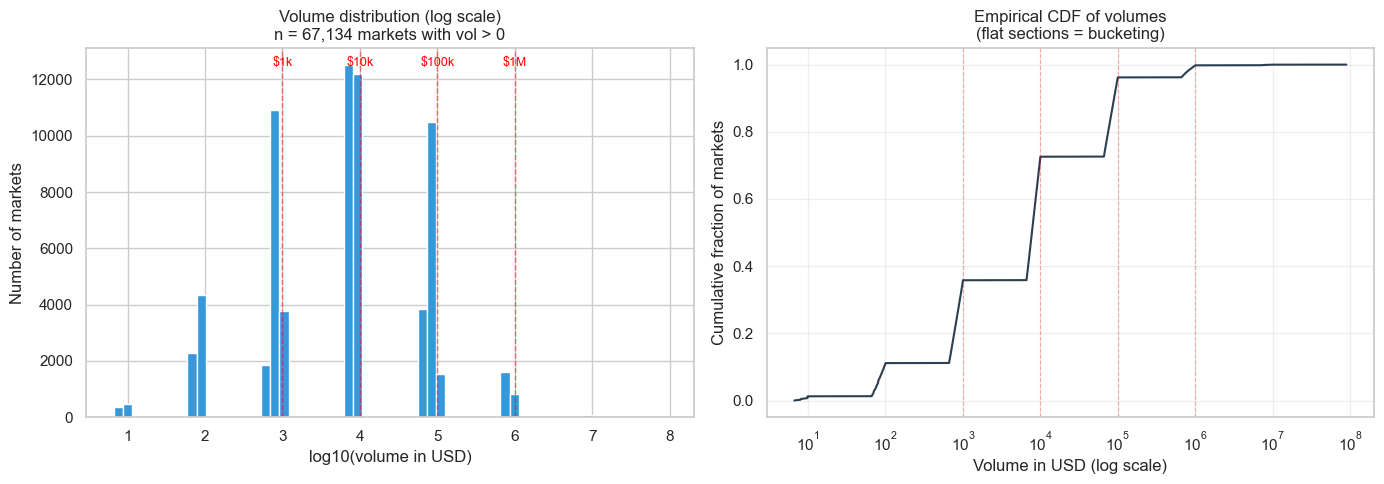

=== Volume distribution statistics ===
Min        : $6.64
P10        : $95.67
Median     : $7,778.52
Mean       : $75,602.22  (much higher than median = heavy tail)
P90        : $89,327.13
P99        : $902,520.77
Max        : $89,652,867.36

=== Bucketing diagnostic ===
  Volume >= $      100:  59,656 markets
  Volume >= $      500:  59,656 markets
  Volume >= $    1,000:  43,096 markets
  Volume >= $    2,000:  43,096 markets
  Volume >= $    5,000:  43,096 markets
  Volume >= $   10,000:  18,404 markets
  Volume >= $   25,000:  18,404 markets
  Volume >= $   50,000:  18,404 markets
  Volume >= $  100,000:   2,555 markets
  Volume >= $  500,000:   2,555 markets

=== Most common exact volume values (top 10) ===
volume_total_usd
10.0000    396
81.0000    390
80.0000    357
70.0000    350
8.0000     269
76.0000    247
90.0000    246
85.0000    231
95.0000    230
96.0000    227


In [76]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

vols = analysis["volume_total_usd"].dropna()
vols_positive = vols[vols > 0]

# Left: log-scale histogram of all volumes
axes[0].hist(np.log10(vols_positive), bins=60, color="#3498db", edgecolor="white")
axes[0].set_xlabel("log10(volume in USD)")
axes[0].set_ylabel("Number of markets")
axes[0].set_title(f"Volume distribution (log scale)\nn = {len(vols_positive):,} markets with vol > 0")
# Add vertical lines at $1k, $10k, $100k, $1M
for v_label, v in [("$1k", 1e3), ("$10k", 1e4), ("$100k", 1e5), ("$1M", 1e6)]:
    axes[0].axvline(np.log10(v), color="red", linestyle="--", alpha=0.5, linewidth=1)
    axes[0].text(np.log10(v), axes[0].get_ylim()[1] * 0.95, v_label,
                 rotation=0, fontsize=9, ha="center", color="red")

# Right: empirical CDF to confirm bucketing
sorted_vols = np.sort(vols_positive)
cdf = np.arange(1, len(sorted_vols) + 1) / len(sorted_vols)
axes[1].plot(sorted_vols, cdf, color="#2c3e50", linewidth=1.5)
axes[1].set_xscale("log")
axes[1].set_xlabel("Volume in USD (log scale)")
axes[1].set_ylabel("Cumulative fraction of markets")
axes[1].set_title("Empirical CDF of volumes\n(flat sections = bucketing)")
axes[1].grid(True, alpha=0.3)
# Reference lines
for v in [1e3, 1e4, 1e5, 1e6]:
    axes[1].axvline(v, color="red", linestyle="--", alpha=0.3, linewidth=0.8)

plt.tight_layout()
plt.show()

# Quantitative confirmation of bucketing
print("=== Volume distribution statistics ===")
print(f"Min        : ${vols_positive.min():,.2f}")
print(f"P10        : ${np.percentile(vols_positive, 10):,.2f}")
print(f"Median     : ${vols_positive.median():,.2f}")
print(f"Mean       : ${vols_positive.mean():,.2f}  (much higher than median = heavy tail)")
print(f"P90        : ${np.percentile(vols_positive, 90):,.2f}")
print(f"P99        : ${np.percentile(vols_positive, 99):,.2f}")
print(f"Max        : ${vols_positive.max():,.2f}")
print()
print("=== Bucketing diagnostic ===")
thresholds = [100, 500, 1000, 2000, 5000, 10000, 25000, 50000, 100000, 500000]
for t in thresholds:
    n = (vols_positive >= t).sum()
    print(f"  Volume >= ${t:>9,}: {n:>7,} markets")
print()
# Look for repeated values
print("=== Most common exact volume values (top 10) ===")
print(vols_positive.round(0).value_counts().head(10).to_string())

## 5. Market Duration

How long do markets typically stay open? A market that runs for 2 hours is
very different from one that runs for 6 months. Duration affects:
- Price information content (longer = more time for the market to aggregate info)
- Which hypotheses apply (late drift only meaningful for markets > 48h)
- Backtest filtering (micro-duration markets may be dominated by liquidity
  providers rather than information traders)

Markets with valid duration: 66,370 / 67,134
  (excluded: 764 with missing or zero duration)



C:\Users\lucas\AppData\Local\Temp\ipykernel_21760\3848591576.py:34: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(data_for_box, labels=top_cats_for_plot, showfliers=False, vert=False)


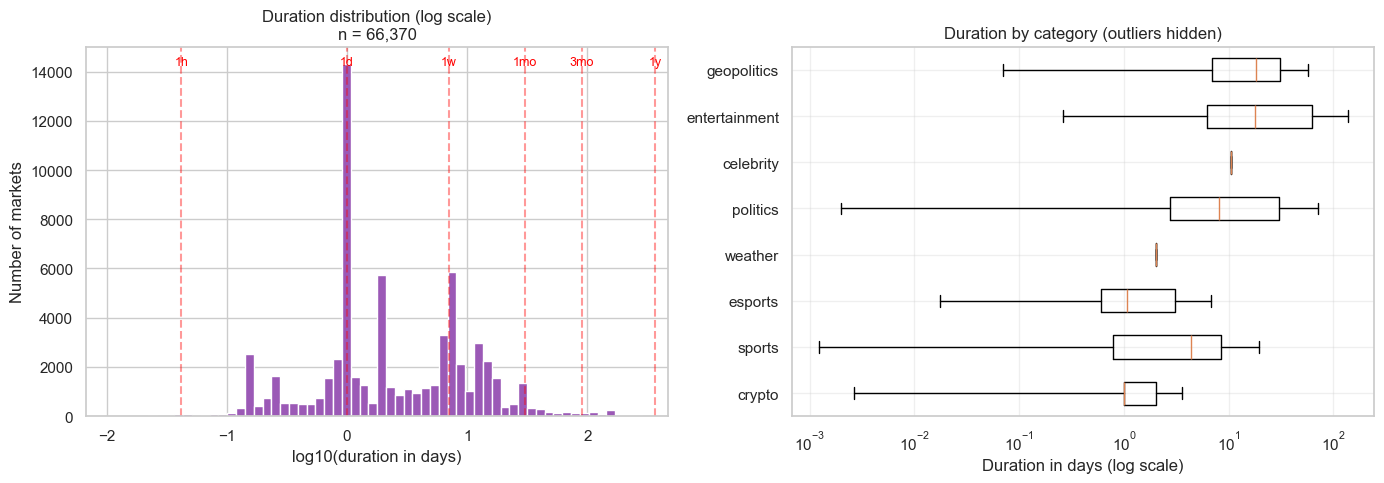

=== Duration statistics (days) ===
Min        : 0.001  (0.0 hours)
P10        : 0.29
Median     : 2.04
Mean       : 7.35
P90        : 14.41
P99        : 104.08
Max        : 282.76

=== Markets by duration bucket ===
  < 1 day         :  19,050  ( 28.7%)
  1d - 1w         :  30,653  ( 46.2%)
  1w - 1mo        :  14,312  ( 21.6%)
  1mo - 3mo       :   1,599  (  2.4%)
  3mo - 1y        :     756  (  1.1%)
  > 1y            :       0  (  0.0%)


In [77]:
# Duration in days from start_ts to end_ts
analysis["duration_days"] = (analysis["end_ts"] - analysis["start_ts"]) / 86400.0

# Some markets may have missing start_ts; exclude
dur = analysis["duration_days"].dropna()
dur_positive = dur[dur > 0]

print(f"Markets with valid duration: {len(dur_positive):,} / {len(analysis):,}")
print(f"  (excluded: {len(analysis) - len(dur_positive):,} with missing or zero duration)")
print()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: histogram of duration (log scale for x-axis since range is huge)
dur_log = np.log10(dur_positive + 0.01)  # +0.01 to avoid log(0)
axes[0].hist(dur_log, bins=60, color="#9b59b6", edgecolor="white")
axes[0].set_xlabel("log10(duration in days)")
axes[0].set_ylabel("Number of markets")
axes[0].set_title(f"Duration distribution (log scale)\nn = {len(dur_positive):,}")
# Annotate key durations
for d_label, d in [("1h", 1/24), ("1d", 1), ("1w", 7), ("1mo", 30), ("3mo", 90), ("1y", 365)]:
    axes[0].axvline(np.log10(d), color="red", linestyle="--", alpha=0.4)
    axes[0].text(np.log10(d), axes[0].get_ylim()[1] * 0.95, d_label,
                 rotation=0, fontsize=9, ha="center", color="red")

# Right: duration by category (boxplot)
dur_by_cat = analysis[analysis["category_derived"] != "other"].copy()
dur_by_cat = dur_by_cat[dur_by_cat["duration_days"] > 0]
top_cats_for_plot = dur_by_cat["category_derived"].value_counts().head(8).index.tolist()
data_for_box = [
    dur_by_cat[dur_by_cat["category_derived"] == c]["duration_days"].values
    for c in top_cats_for_plot
]
axes[1].boxplot(data_for_box, labels=top_cats_for_plot, showfliers=False, vert=False)
axes[1].set_xscale("log")
axes[1].set_xlabel("Duration in days (log scale)")
axes[1].set_title("Duration by category (outliers hidden)")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Statistics
print("=== Duration statistics (days) ===")
print(f"Min        : {dur_positive.min():.3f}  ({dur_positive.min()*24:.1f} hours)")
print(f"P10        : {np.percentile(dur_positive, 10):.2f}")
print(f"Median     : {dur_positive.median():.2f}")
print(f"Mean       : {dur_positive.mean():.2f}")
print(f"P90        : {np.percentile(dur_positive, 90):.2f}")
print(f"P99        : {np.percentile(dur_positive, 99):.2f}")
print(f"Max        : {dur_positive.max():.2f}")
print()
print("=== Markets by duration bucket ===")
buckets = [
    (0, 1, "< 1 day"),
    (1, 7, "1d - 1w"),
    (7, 30, "1w - 1mo"),
    (30, 90, "1mo - 3mo"),
    (90, 365, "3mo - 1y"),
    (365, 99999, "> 1y"),
]
for lo, hi, label in buckets:
    n = ((dur_positive >= lo) & (dur_positive < hi)).sum()
    pct = n / len(dur_positive) * 100
    print(f"  {label:15s} : {n:>7,}  ({pct:>5.1f}%)")

## 6. Price at T-24h Distribution

This is the key input distribution for Hypothesis H1 (favorite-longshot bias).
For each market, we extract the YES price 24 hours before resolution, which
is our "market forecast" to be compared against the realized outcome.

Key questions:
- How many markets have usable T-24h prices? (some have too short history)
- Is the distribution concentrated around 0.5, or are there modes at the extremes?
- Do prices show artificial clustering (e.g., at 0.50 exactly) that would
  indicate thin trading?

In [78]:
# Extract the YES price 24h before end_ts for each market in analysis_set,
# using pandas' merge_asof for O(n log n) performance.

conn = sqlite3.connect(DB_PATH)
prices_df = pd.read_sql_query(
    "SELECT token_id, ts, price FROM price_history",
    conn,
)
conn.close()

print(f"Loaded {len(prices_df):,} price points across {prices_df['token_id'].nunique():,} tokens")

HOURS_BEFORE_CLOSE = 24
OFFSET_SEC = HOURS_BEFORE_CLOSE * 3600

# Prepare the left side
left = analysis.dropna(subset=["yes_token_id", "end_ts"]).copy()
left["target_ts"] = (left["end_ts"] - OFFSET_SEC).astype("int64")   # force int64
left = left.rename(columns={"yes_token_id": "token_id"})
left = left[["market_id", "token_id", "target_ts", "category_derived",
             "duration_days", "resolved_outcome"]]
left = left.sort_values("target_ts").reset_index(drop=True)

# Prepare the right side
right = prices_df.copy()
right["ts"] = right["ts"].astype("int64")                            # force int64
right = right.sort_values("ts").reset_index(drop=True)

print(f"\nLeft dtypes : target_ts={left['target_ts'].dtype}, token_id={left['token_id'].dtype}")
print(f"Right dtypes: ts={right['ts'].dtype}, token_id={right['token_id'].dtype}")

# As-of join
t24h_df = pd.merge_asof(
    left,
    right,
    left_on="target_ts",
    right_on="ts",
    by="token_id",
    direction="backward",
    allow_exact_matches=True,
)

# Keep only successful matches
t24h_df = t24h_df.dropna(subset=["price"]).copy()
t24h_df = t24h_df.rename(columns={"price": "price_t24h"})
t24h_df = t24h_df[["market_id", "category_derived", "duration_days",
                    "resolved_outcome", "price_t24h"]]

print(f"\nMarkets with T-24h price: {len(t24h_df):,} / {len(left):,} ({len(t24h_df)/len(left):.1%})")
print(f"Markets excluded (insufficient history): {len(left) - len(t24h_df):,}")

Loaded 1,361,079 price points across 46,930 tokens

Left dtypes : target_ts=int64, token_id=object
Right dtypes: ts=int64, token_id=object

Markets with T-24h price: 11,340 / 67,134 (16.9%)
Markets excluded (insufficient history): 55,794


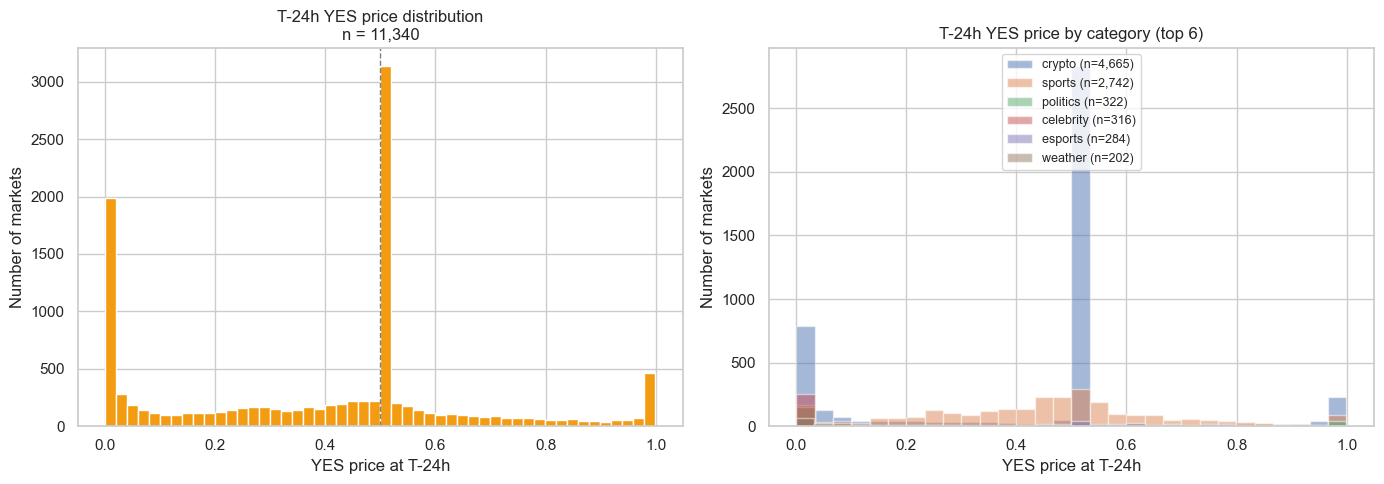

=== T-24h price statistics ===
Min     : 0.0005
P10     : 0.0030
Median  : 0.4900
Mean    : 0.3905
P90     : 0.7350
Max     : 0.9995

=== Markets by price decile (crucial for H1) ===
 decile    n  yes_rate
0.0-0.1 2717    0.0199
0.1-0.2  551    0.1779
0.2-0.3  766    0.3251
0.3-0.4  736    0.4144
0.4-0.5 3762    0.5043
0.5-0.6 1073    0.4800
0.6-0.7  465    0.6172
0.7-0.8  357    0.7087
0.8-0.9  245    0.8653
0.9-1.0  668    0.9731


In [81]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: overall distribution
axes[0].hist(t24h_df["price_t24h"], bins=50, color="#f39c12", edgecolor="white")
axes[0].set_xlabel("YES price at T-24h")
axes[0].set_ylabel("Number of markets")
axes[0].set_title(f"T-24h YES price distribution\nn = {len(t24h_df):,}")
axes[0].axvline(0.5, color="black", linestyle="--", alpha=0.5, linewidth=1)

# Right: distribution by category (top 6, excluding "other")
top6_cats = (
    t24h_df[t24h_df["category_derived"] != "other"]["category_derived"]
    .value_counts().head(6).index.tolist()
)
for i, cat in enumerate(top6_cats):
    subset = t24h_df[t24h_df["category_derived"] == cat]["price_t24h"]
    axes[1].hist(subset, bins=30, alpha=0.5, label=f"{cat} (n={len(subset):,})")
axes[1].set_xlabel("YES price at T-24h")
axes[1].set_ylabel("Number of markets")
axes[1].set_title("T-24h YES price by category (top 6)")
axes[1].legend(loc="upper center", fontsize=9)

plt.tight_layout()
plt.show()

# Statistics
print("=== T-24h price statistics ===")
print(f"Min     : {t24h_df['price_t24h'].min():.4f}")
print(f"P10     : {t24h_df['price_t24h'].quantile(0.10):.4f}")
print(f"Median  : {t24h_df['price_t24h'].median():.4f}")
print(f"Mean    : {t24h_df['price_t24h'].mean():.4f}")
print(f"P90     : {t24h_df['price_t24h'].quantile(0.90):.4f}")
print(f"Max     : {t24h_df['price_t24h'].max():.4f}")
print()
print("=== Markets by price decile (crucial for H1) ===")
bins = np.linspace(0, 1, 11)
t24h_df["decile"] = pd.cut(t24h_df["price_t24h"], bins=bins, include_lowest=True, labels=[f"{b:.1f}-{bins[i+1]:.1f}" for i, b in enumerate(bins[:-1])])
decile_counts = t24h_df.groupby("decile", observed=True).agg(
    n=("price_t24h", "count"),
    yes_rate=("resolved_outcome", lambda x: (x == "YES").mean()),
).reset_index()
print(decile_counts.to_string(index=False))

## 7. Sanity Checks

Final verification before closing the exploration:
- Are there markets with impossible values (negative duration, price outside [0,1])?
- Are there markets where the T-24h price equals the final outcome suspiciously often (possible time alignment bug)?
- Are there duplicate market_ids?

In [82]:
print("=== Sanity Checks ===\n")

# 1. Negative or zero durations
n_bad_dur = (analysis["duration_days"] <= 0).sum()
print(f"Markets with duration <= 0     : {n_bad_dur:,}")

# 2. Prices outside [0, 1]
n_bad_price = ((t24h_df["price_t24h"] < 0) | (t24h_df["price_t24h"] > 1)).sum()
print(f"T-24h prices outside [0,1]     : {n_bad_price:,}")

# 3. Duplicate market_ids in markets table
n_dup = markets["market_id"].duplicated().sum()
print(f"Duplicate market_ids           : {n_dup:,}")

# 4. Markets with NULL outcomes in analysis_set (should be 0 by construction)
n_null_outcome = analysis["resolved_outcome"].isna().sum()
print(f"Null outcomes in analysis_set  : {n_null_outcome:,}")

# 5. Extreme prices: how many at exactly 0, 0.5, 1?
p = t24h_df["price_t24h"]
print(f"\nT-24h prices at exactly 0.0    : {(p == 0.0).sum():,}")
print(f"T-24h prices at exactly 0.5    : {(p == 0.5).sum():,}")
print(f"T-24h prices at exactly 1.0    : {(p == 1.0).sum():,}")

# 6. Concordance: when price is high, is outcome actually YES more often?
# Quick sanity: correlation between price and binary outcome
t24h_df["outcome_bin"] = (t24h_df["resolved_outcome"] == "YES").astype(int)
correlation = t24h_df[["price_t24h", "outcome_bin"]].corr().iloc[0, 1]
print(f"\nCorrelation(price_T24h, outcome YES=1): {correlation:.4f}")
print(f"  (if ~ 0, prices are uninformative; if ~ 1, prices are very informative)")

# 7. Brier score overall (preview of H1)
brier = ((t24h_df["price_t24h"] - t24h_df["outcome_bin"]) ** 2).mean()
print(f"\nOverall Brier score            : {brier:.4f}")
print(f"  (perfect calibration = 0; random = 0.25; always 0.5 = 0.25)")

=== Sanity Checks ===

Markets with duration <= 0     : 764
T-24h prices outside [0,1]     : 0
Duplicate market_ids           : 0
Null outcomes in analysis_set  : 0

T-24h prices at exactly 0.0    : 0
T-24h prices at exactly 0.5    : 2,731
T-24h prices at exactly 1.0    : 0

Correlation(price_T24h, outcome YES=1): 0.5408
  (if ~ 0, prices are uninformative; if ~ 1, prices are very informative)

Overall Brier score            : 0.1698
  (perfect calibration = 0; random = 0.25; always 0.5 = 0.25)


### Interprétation des résultats clés — lecture en français

**Distribution des prix T-24h :**
On observe trois modes dans la distribution :
- Un pic massif à 0.50 (~3 000 marchés), dominé par la catégorie crypto,
  probablement dû à des marchés binaires peu tradés qui restent au prix
  par défaut jusqu'à proximité de la résolution.
- Un pic à 0.00 (~2 000 marchés) : marchés "déjà perdus" 24h avant clôture.
- Un pic à 1.00 (~400 marchés) : marchés "déjà gagnés" 24h avant clôture.

Entre 0.1 et 0.9, la distribution est étonnamment plate.

**Sanity checks principaux :**
- Corrélation(price_T24h, outcome) = 0.54 : prix significativement informatifs
- Brier score global = 0.17 : bien meilleur qu'aléatoire (0.25), mais loin
  de la perfection (0.0)
- 2 731 marchés exactement à 0.50 → symptôme probable d'illiquidité

**Aperçu de H1 (table des déciles) :**
La calibration est globalement correcte mais deux anomalies se dessinent :
- Décile le plus bas : prix moyens ~0.05, YES rate réel ~2% → léger biais
  où le marché surestime les outsiders
- Décile le plus haut (0.8-0.9) : prix moyens ~0.85, YES rate réel 87% →
  léger biais où le marché sous-estime les favoris

Ces écarts apparents sont cohérents avec le classique **favorite-longshot
bias** documenté depuis 1949 dans les marchés de paris. Le notebook 02
testera formellement si ces écarts sont statistiquement significatifs
après correction pour tests multiples et stratification par catégorie.